# Unified Agent Comparison Notebook

This notebook provides a unified framework to compare different agents (PRF, Reranking) against BM25 baseline.
Configure parameters in Cell 1 to select which agent to run.

In [36]:
# ============================================================================
# CELL 1: CONSTANTS AND PARAMETERS
# ============================================================================

# ===== FILE PATHS =====
DATA_FILE = "msmarco_queries_50_100_qrels.csv"

# ===== RETRIEVAL PARAMETERS =====
TOP_K = 10
NUM_QUERIES = 5

# ===== AGENT PARAMETERS =====
NUM_EXPANSION_TERMS = 2  # For PRF agent

# ===== AGENT SELECTION =====
AGENT_SELECTION = [0, 0, 1]  # PRF Reranking Reformulate

# Get selected agent info
AGENT_NAMES = ["PRF", "Reranking", "Reformulate"]
selected_agent_id = AGENT_SELECTION.index(1) if 1 in AGENT_SELECTION else None
selected_agent_name = AGENT_NAMES[selected_agent_id] if selected_agent_id is not None else None

if selected_agent_name is None:
    raise ValueError("No agent selected! Set exactly one position to 1 in AGENT_SELECTION")

print(f"✓ Configuration loaded")
print(f"  Data file: {DATA_FILE}")
print(f"  Top-K: {TOP_K}")
print(f"  Selected Agent: {selected_agent_name} (ID: {selected_agent_id})")
print(f"  Number of queries: {NUM_QUERIES}")

✓ Configuration loaded
  Data file: msmarco_queries_50_100_qrels.csv
  Top-K: 10
  Selected Agent: Reformulate (ID: 2)
  Number of queries: 5


In [37]:
# ============================================================================
# CELL 2: SETUP - All imports, initialization, and utility functions
# ============================================================================

import sys
from pathlib import Path
import pandas as pd
import numpy as np
from collections import defaultdict
from typing import Dict, List, Tuple
import logging
import matplotlib.pyplot as plt

# Add src to path
src_path = Path.cwd().parent / "src"
sys.path.insert(0, str(src_path))

from sentence_transformers import SentenceTransformer
from src.utils.retriever import Retriever, create_retriever_callable
from src.agents.prf import PRFAgent
from src.agents.rerank import RerankingAgent
from src.agents.reformulate import ReformulationAgent
from src.simulation import Simulation

# Configure logging
logging.basicConfig(level=logging.WARNING)
logger = logging.getLogger(__name__)

print("✓ All libraries imported successfully")

# Load the CSV file with qrels
data_path = Path.cwd() / DATA_FILE

if not data_path.exists():
    print(f"⚠️  Warning: CSV not found at {data_path}")
    print(f"Please ensure {DATA_FILE} exists in data directory")
else:
    df_qrels = pd.read_csv(data_path)
    print(f"✓ Loaded qrels CSV with {len(df_qrels)} entries")
    print(f"✓ Unique queries: {df_qrels['query_id'].nunique()}")
    print(f"\nSample entries:")
    print(df_qrels.head())

# Get unique queries
sample_queries = sorted(df_qrels['query_id'].unique())[:NUM_QUERIES]
print(f"\n✓ Will evaluate {len(sample_queries)} queries: {sample_queries}")

# Initialize sentence transformer (for embedding)
print("\nLoading sentence transformer model...")
encoder = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
print("✓ Encoder loaded")

# Initialize retriever
print("Setting up retriever...")
retriever_instance = Retriever()
retriever_func = create_retriever_callable(retriever_instance)
print("✓ Retriever initialized")

# Initialize selected agent
print(f"Setting up {selected_agent_name} agent...")
if selected_agent_id == 0:  # PRF
    agent = PRFAgent(embed_model=encoder, num_expansion_terms=NUM_EXPANSION_TERMS)
elif selected_agent_id == 1:  # Reranking
    agent = RerankingAgent(embed_model=encoder)
elif selected_agent_id == 2:  # Reformulate
    agent = ReformulationAgent(embed_model=encoder)
print(f"✓ {selected_agent_name} agent initialized")

# Helper function to normalize doc_ids
def normalize_doc_id(doc_id):
    """
    Extract the base doc_id from retriever format.
    Retriever format: msmarco_v2.1_doc_52_1062570315#1_2098008849
    Qrels format: msmarco_v2.1_doc_02_680722105
    Extract the part before # to match qrels format
    """
    if '#' in doc_id:
        return doc_id.split('#')[0]
    return doc_id

# Build lookup dict for graded relevance: (query_id, doc_id) -> relevance
qrels_lookup = {}
for _, row in df_qrels.iterrows():
    qrels_lookup[(row['query_id'], row['doc_id'])] = row['relevance']
print(f"Loaded {len(qrels_lookup)} qrels entries")
print(f"Loaded {len(qrels_lookup)} qrels entries")

# Define NDCG@K Calculation Functions
def compute_dcg(relevances: List[int], k: int = 10) -> float:
    """
    Compute DCG@k given a list of relevance scores.
    
    DCG@k = sum_{i=1}^{k} (2^rel_i - 1) / log2(i + 1)
    """
    dcg = 0.0
    for i, rel in enumerate(relevances[:k]):
        if rel > 0:
            dcg += (2 ** rel - 1) / np.log2(i + 2)  # i+2 because ranking is 1-indexed
    return dcg


def compute_ndcg(graded_relevance: List[int], query_id: str, k: int = 10) -> float:
    """
    Compute NDCG@k.
    
    Args:
        graded_relevance: List of graded relevance scores
        query_id: Query ID for looking up ideal gains
        k: Cutoff for NDCG calculation
    
    Returns:
        NDCG@k score in [0, 1]
    """
    # Compute DCG
    dcg = compute_dcg(graded_relevance, k)
    
    # Compute ideal DCG using actual relevance values for this query
    query_qrels = df_qrels[df_qrels['query_id'] == query_id]
    ideal_gains = sorted(query_qrels['relevance'].values, reverse=True)
    idcg = compute_dcg(ideal_gains, k)
    
    # Compute NDCG
    ndcg = dcg / idcg if idcg > 0 else 0.0
    return ndcg


print("\n✓ NDCG calculation functions defined")
print("\n" + "="*80)

print("SETUP COMPLETE - Ready for comparison")
print("="*80)

INFO:sentence_transformers.SentenceTransformer:Use pytorch device_name: cpu
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2
INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/modules.json "HTTP/1.1 200 OK"


✓ All libraries imported successfully
✓ Loaded qrels CSV with 1277 entries
✓ Unique queries: 18

Sample entries:
   query_id                            query_text  \
0   2005861  what are the three countries in 1984   
1   2005861  what are the three countries in 1984   
2   2005861  what are the three countries in 1984   
3   2005861  what are the three countries in 1984   
4   2005861  what are the three countries in 1984   

                           doc_id  relevance  
0   msmarco_v2.1_doc_00_388740946          1  
1  msmarco_v2.1_doc_01_1066810610          2  
2   msmarco_v2.1_doc_04_943106501          1  
3   msmarco_v2.1_doc_05_695295296          3  
4    msmarco_v2.1_doc_06_74448072          3  

✓ Will evaluate 5 queries: [np.int64(2005861), np.int64(2006211), np.int64(2006394), np.int64(2006627), np.int64(2016333)]

Loading sentence transformer model...


INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/config_sentence_transformers.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/config_sentence_transformers.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentenc

✓ Encoder loaded
Setting up retriever...
✓ Retriever initialized
Setting up Reformulate agent...
✓ Reformulate agent initialized
Loaded 1277 qrels entries
Loaded 1277 qrels entries

✓ NDCG calculation functions defined

SETUP COMPLETE - Ready for comparison


In [32]:
# ============================================================================
# CELL 3: BASELINE - BM25 Retrieval and NDCG Calculation
# ============================================================================

baseline_results_dict = {}
baseline_ndcg_scores = {}
baseline_raw_results = {}  # Store raw results for agent to reuse

print("\n" + "="*80)
print("BASELINE: BM25 RETRIEVAL")
print("="*80)

# Process each query
for query_id in sample_queries:
    query_row = df_qrels[df_qrels['query_id'] == query_id].iloc[0]
    query_text = query_row['query_text']
    
    print(f"\nQuery {query_id}: {query_text}")
    
    # Retrieve top k documents
    baseline_doc_ids, baseline_scores, baseline_corpus = retriever_func(query_text, top_k=TOP_K)
    
    # Store raw results for agent to reuse
    baseline_raw_results[query_id] = (baseline_doc_ids, baseline_scores, baseline_corpus)
    
    # Create graded relevance list by looking up actual relevance scores
    graded_relevance = [qrels_lookup.get((query_id, normalize_doc_id(doc_id)), 0) for doc_id in baseline_doc_ids]
    
    baseline_results_dict[query_id] = graded_relevance
    print(f"  Retrieved docs: {baseline_doc_ids[:3]}...")
    print(f"  Normalized: {[normalize_doc_id(d) for d in baseline_doc_ids[:3]]}...")
    print(f"  Graded relevance: {graded_relevance}")
    
    # Calculate NDCG
    ndcg = compute_ndcg(graded_relevance, query_id, k=TOP_K)
    baseline_ndcg_scores[query_id] = ndcg
    print(f"  NDCG@{TOP_K}: {ndcg:.4f}")

print("\n" + "="*80)
print("BASELINE RESULTS")
print("="*80)
for query_id, ndcg in baseline_ndcg_scores.items():
    print(f"Query {query_id}: NDCG@{TOP_K} = {ndcg:.4f}")

baseline_mean = np.mean(list(baseline_ndcg_scores.values()))
print(f"\nMean Baseline NDCG@{TOP_K}: {baseline_mean:.4f}")


BASELINE: BM25 RETRIEVAL

Query 2005861: what are the three countries in 1984


c:\Users\hanaz\Documents\GitHub\Multi-Agent-Ensemble-for-Search-Through-Reinforcement-Optimization-MAESTRO-\.venv\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'opensearch.pads.fim.uni-passau.de'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  Retrieved docs: ['msmarco_v2.1_doc_13_267346721#0_631972288', 'msmarco_v2.1_doc_36_598978357#5_1202570400', 'msmarco_v2.1_doc_13_548647086#10_1264381331']...
  Normalized: ['msmarco_v2.1_doc_13_267346721', 'msmarco_v2.1_doc_36_598978357', 'msmarco_v2.1_doc_13_548647086']...
  Graded relevance: [0, 2, 0, 0, 0, 0, 0, 0, 0, 0]
  NDCG@10: 0.0595

Query 2006211: what does auslan interpreted performance mean


c:\Users\hanaz\Documents\GitHub\Multi-Agent-Ensemble-for-Search-Through-Reinforcement-Optimization-MAESTRO-\.venv\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'opensearch.pads.fim.uni-passau.de'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  Retrieved docs: ['msmarco_v2.1_doc_10_465221469#0_853187414', 'msmarco_v2.1_doc_10_465221469#1_853189560', 'msmarco_v2.1_doc_33_773946582#2_1613196818']...
  Normalized: ['msmarco_v2.1_doc_10_465221469', 'msmarco_v2.1_doc_10_465221469', 'msmarco_v2.1_doc_33_773946582']...
  Graded relevance: [1, 1, 1, 0, 1, 1, 0, 1, 0, 3]
  NDCG@10: 0.1770

Query 2006394: what does septrin heal?


...

  Retrieved docs: ['msmarco_v2.1_doc_04_667663003#14_1452776484', 'msmarco_v2.1_doc_48_560650934#0_1026477529', 'msmarco_v2.1_doc_00_800449134#0_1486615757']...
  Normalized: ['msmarco_v2.1_doc_04_667663003', 'msmarco_v2.1_doc_48_560650934', 'msmarco_v2.1_doc_00_800449134']...
  Graded relevance: [0, 2, 1, 2, 1, 1, 1, 0, 2, 0]
  NDCG@10: 0.4156

Query 2006627: what is 311 for


c:\Users\hanaz\Documents\GitHub\Multi-Agent-Ensemble-for-Search-Through-Reinforcement-Optimization-MAESTRO-\.venv\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'opensearch.pads.fim.uni-passau.de'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  Retrieved docs: ['msmarco_v2.1_doc_00_113797779#3_204685247', 'msmarco_v2.1_doc_00_113797779#2_204684237', 'msmarco_v2.1_doc_00_113797779#1_204683323']...
  Normalized: ['msmarco_v2.1_doc_00_113797779', 'msmarco_v2.1_doc_00_113797779', 'msmarco_v2.1_doc_00_113797779']...
  Graded relevance: [0, 0, 0, 3, 0, 2, 3, 2, 2, 1]
  NDCG@10: 0.2690

Query 2016333: how to make ground beef empanadas


c:\Users\hanaz\Documents\GitHub\Multi-Agent-Ensemble-for-Search-Through-Reinforcement-Optimization-MAESTRO-\.venv\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'opensearch.pads.fim.uni-passau.de'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  Retrieved docs: ['msmarco_v2.1_doc_55_12974461#2_33211105', 'msmarco_v2.1_doc_47_1182413403#4_2570560213', 'msmarco_v2.1_doc_47_1182413403#3_2570558351']...
  Normalized: ['msmarco_v2.1_doc_55_12974461', 'msmarco_v2.1_doc_47_1182413403', 'msmarco_v2.1_doc_47_1182413403']...
  Graded relevance: [0, 2, 2, 2, 2, 2, 2, 2, 0, 2]
  NDCG@10: 0.5517

BASELINE RESULTS
Query 2005861: NDCG@10 = 0.0595
Query 2006211: NDCG@10 = 0.1770
Query 2006394: NDCG@10 = 0.4156
Query 2006627: NDCG@10 = 0.2690
Query 2016333: NDCG@10 = 0.5517

Mean Baseline NDCG@10: 0.2946


In [38]:
# ============================================================================
# CELL 4: AGENT ENHANCEMENT - Selected Agent and NDCG Calculation
# ============================================================================

agent_results_dict = {}
agent_ndcg_scores = {}

print("\n" + "="*80)
print(f"AGENT ENHANCEMENT: BM25 + {selected_agent_name.upper()}")
print("="*80)

# Process each query
for query_id in sample_queries:
    query_row = df_qrels[df_qrels['query_id'] == query_id].iloc[0]
    query_text = query_row['query_text']
    
    print(f"\nQuery {query_id}: {query_text}")
    
    # Reuse baseline retrieval results
    baseline_doc_ids, baseline_scores, baseline_corpus = baseline_raw_results[query_id]
    raw_results = (baseline_doc_ids, baseline_scores, baseline_corpus)
    
    # Apply agent enhancement
    if selected_agent_id == 0:  # PRF
        query_features = {
            'query_text': query_text,
            'retriever': retriever_func,
            'top_k': TOP_K
        }
        agent_effects = agent.compute_effects(query_features, raw_results=raw_results)
        agent_doc_ids = agent_effects['new_doc_ids']
    
    elif selected_agent_id == 1:  # Reranking
        query_features = {
            'query_text': query_text,
            'doc_ids': baseline_doc_ids,
            'doc_scores': baseline_scores,
            'corpus': baseline_corpus,
            'top_k_rerank': TOP_K
        }
        agent_effects = agent.compute_effects(query_features)
        agent_doc_ids = agent_effects['new_doc_ids']
    
    elif selected_agent_id == 2:  # Reformulate
        query_features = {
            'query_text': query_text,
            'retriever': retriever_func,
            'top_k': TOP_K
        }
        agent_effects = agent.compute_effects(query_features)
        agent_doc_ids = agent_effects['new_doc_ids']
        reformulated_query = agent_effects['new_query_text']
        print(f"  Reformulated query: {reformulated_query}")
    
    # Create graded relevance list by looking up actual relevance scores
    graded_relevance = [qrels_lookup.get((query_id, normalize_doc_id(doc_id)), 0) for doc_id in agent_doc_ids]
    
    agent_results_dict[query_id] = graded_relevance
    print(f"  Retrieved docs: {agent_doc_ids[:3]}...")
    print(f"  Normalized: {[normalize_doc_id(d) for d in agent_doc_ids[:3]]}...")
    print(f"  Graded relevance: {graded_relevance}")
    
    # Calculate NDCG
    ndcg = compute_ndcg(graded_relevance, query_id, k=TOP_K)
    agent_ndcg_scores[query_id] = ndcg
    print(f"  NDCG@{TOP_K}: {ndcg:.4f}")

print("\n" + "="*80)
print(f"{selected_agent_name.upper()} RESULTS")
print("="*80)
for query_id, ndcg in agent_ndcg_scores.items():
    print(f"Query {query_id}: NDCG@{TOP_K} = {ndcg:.4f}")

agent_mean = np.mean(list(agent_ndcg_scores.values()))
print(f"\nMean {selected_agent_name} NDCG@{TOP_K}: {agent_mean:.4f}")


AGENT ENHANCEMENT: BM25 + REFORMULATE

Query 2005861: what are the three countries in 1984


INFO:httpx:HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"
c:\Users\hanaz\Documents\GitHub\Multi-Agent-Ensemble-for-Search-Through-Reinforcement-Optimization-MAESTRO-\.venv\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'opensearch.pads.fim.uni-passau.de'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Raw retrieval results: (['msmarco_v2.1_doc_33_1347699514#6_2883757796', 'msmarco_v2.1_doc_33_1347699514#7_2883759786', 'msmarco_v2.1_doc_33_1320269301#5_2809905460', 'msmarco_v2.1_doc_33_1329675366#10_2835123257', 'msmarco_v2.1_doc_55_200438479#0_467283348', 'msmarco_v2.1_doc_48_1224681744#0_2235212387', 'msmarco_v2.1_doc_13_267346721#0_631972288', 'msmarco_v2.1_doc_49_385436824#12_785014078', 'msmarco_v2.1_doc_33_1325381091#4_2823477681', 'msmarco_v2.1_doc_33_1325381091#5_2823480074'], array([60.950935, 59.091843, 53.174   , 52.793194, 52.25404 , 51.607925,
       51.44239 , 50.529964, 49.28175 , 48.886826], dtype=float32), {'msmarco_v2.1_doc_33_1347699514#6_2883757796': "The Party Has Many Slogans   In George Orwell's 1984, the Party, the government of Oceania, has many slogans. One of the sayings is “Big Brother Is Watching You”. Despite the fact that the slogan is only mentioned a few times throughout the novel, it embodies the government that Orwell has created. We first learn of 

INFO:httpx:HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"
c:\Users\hanaz\Documents\GitHub\Multi-Agent-Ensemble-for-Search-Through-Reinforcement-Optimization-MAESTRO-\.venv\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'opensearch.pads.fim.uni-passau.de'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Raw retrieval results: (['msmarco_v2.1_doc_10_465221469#0_853187414', 'msmarco_v2.1_doc_33_773946582#1_1613195375', 'msmarco_v2.1_doc_10_465221469#1_853189560', 'msmarco_v2.1_doc_02_1533804759#5_2582051556', 'msmarco_v2.1_doc_05_1298338523#6_2484657269', 'msmarco_v2.1_doc_34_444955066#19_962432142', 'msmarco_v2.1_doc_04_457688511#0_1052841340', 'msmarco_v2.1_doc_22_1691479467#2_3584037083', 'msmarco_v2.1_doc_04_457688511#2_1052844488', 'msmarco_v2.1_doc_25_221884351#4_427368786'], array([103.44777 ,  99.69071 ,  98.39886 ,  97.620346,  95.94693 ,
        94.109215,  93.8297  ,  93.15484 ,  92.62972 ,  91.92186 ],
      dtype=float32), {'msmarco_v2.1_doc_10_465221469#0_853187414': 'Learn Auslan | Expression Australia\nSkip to main content\nEnter Keyword to Search\nWork with us\nSupport our work\nDonate\nWork with us\nSupport our work\nDonate\nMenu\nEnter Keyword to Search\nHome\nAbout\nAbout Expression Australia\nOur Impact\nOur History\nOur Partners and Projects\nOur Board and Manageme

...

Raw retrieval results: (['msmarco_v2.1_doc_02_145786124#2_250558029', 'msmarco_v2.1_doc_02_145786124#3_250559367', 'msmarco_v2.1_doc_25_1484921942#0_2876611517', 'msmarco_v2.1_doc_04_667663003#14_1452776484', 'msmarco_v2.1_doc_25_1484921942#1_2876613753', 'msmarco_v2.1_doc_00_800475435#0_1486641983', 'msmarco_v2.1_doc_24_388896668#2_854564926', 'msmarco_v2.1_doc_48_509462154#1_905864240', 'msmarco_v2.1_doc_07_997141395#1_1763565614', 'msmarco_v2.1_doc_04_966191188#5_2008324778'], array([130.44292 , 123.05755 , 112.968376, 111.132866, 110.762825,
       109.21981 , 108.033615, 106.72006 , 105.94647 , 104.28356 ],
      dtype=float32), {'msmarco_v2.1_doc_02_145786124#2_250558029': "Published by Houghton Mifflin Company. All rights reserved. sulfamethoxazole/trimethoprim\nBactrim, see there. McGraw-Hill Concise Dictionary of Modern Medicine. © 2002 by The McGraw-Hill Companies, Inc.\ntri·meth·o·prim\n(TMP) ( trī-meth'ō-prim)\nAn antimicrobial agent that potentiates the effect of sulfonami

INFO:httpx:HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"
c:\Users\hanaz\Documents\GitHub\Multi-Agent-Ensemble-for-Search-Through-Reinforcement-Optimization-MAESTRO-\.venv\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'opensearch.pads.fim.uni-passau.de'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Raw retrieval results: (['msmarco_v2.1_doc_41_1789594777#0_2804258628', 'msmarco_v2.1_doc_51_1097437290#1_2257444489', 'msmarco_v2.1_doc_24_1571063431#0_3356309883', 'msmarco_v2.1_doc_23_667027300#2_1470875669', 'msmarco_v2.1_doc_23_667027300#1_1470873574', 'msmarco_v2.1_doc_41_1789594777#1_2804259958', 'msmarco_v2.1_doc_36_491109089#0_965680260', 'msmarco_v2.1_doc_04_1245195542#0_2557648520', 'msmarco_v2.1_doc_02_1255193860#1_2117673069', 'msmarco_v2.1_doc_08_1247195136#0_2250872332'], array([108.53847 , 107.09051 ,  99.65077 ,  98.69881 ,  98.67839 ,
        98.59556 ,  94.89266 ,  93.693855,  93.087715,  90.65903 ],
      dtype=float32), {'msmarco_v2.1_doc_41_1789594777#0_2804258628': 'What Is 311? Digital Communities\nWhat Is 311? Cities have benefited greatly from the merger of technology with a three-number hotline. The result: better service delivery for citizens and more data about how to run local government. What do you call 311 for? 311 is a non-emergency phone number that p

INFO:httpx:HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"
c:\Users\hanaz\Documents\GitHub\Multi-Agent-Ensemble-for-Search-Through-Reinforcement-Optimization-MAESTRO-\.venv\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'opensearch.pads.fim.uni-passau.de'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Raw retrieval results: (['msmarco_v2.1_doc_06_1304659884#0_1729162377', 'msmarco_v2.1_doc_23_185754779#0_421363852', 'msmarco_v2.1_doc_45_552291424#12_976867876', 'msmarco_v2.1_doc_47_1182413403#3_2570558351', 'msmarco_v2.1_doc_25_1294729512#2_2444993297', 'msmarco_v2.1_doc_45_552167539#0_976622076', 'msmarco_v2.1_doc_47_1182413403#4_2570560213', 'msmarco_v2.1_doc_06_1304659884#18_1729188605', 'msmarco_v2.1_doc_45_80939266#2_177699740', 'msmarco_v2.1_doc_55_12974461#1_33209765'], array([64.002014, 63.64927 , 63.480892, 63.074623, 62.253834, 61.813927,
       61.363068, 60.956234, 60.732395, 60.696983], dtype=float32), {'msmarco_v2.1_doc_06_1304659884#0_1729162377': "How to Make Empanadas - Handle the Heat\nFiled Under: Appetizer | Beef | How To | Latin | Lunch | Main Dish | Videos\nHow to Make Empanadas\nRecipe By Tessa Arias\n|\nJune 10th, 2015\n4.86 from 14 votes\n51 Comments\nLeave a Review / Comment\nRead Comments\n4.86 from 14 votes\n51 Comments\nLeave a Review / Comment\nRead Com

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.



COMPARISON TABLE: BASELINE vs BM25+REFORMULATE

 Query ID Baseline NDCG Reformulate NDCG  Δ NDCG      Δ %
  2005861        0.0595           0.1256 +0.0660 +110.98%
  2006211        0.1770           0.2654 +0.0884  +49.91%
  2006394        0.4156           0.1679 -0.2477  -59.60%
  2006627        0.2690           0.8298 +0.5608 +208.50%
  2016333        0.5517           0.4796 -0.0721  -13.07%

SUMMARY STATISTICS
Baseline Mean NDCG@10: 0.2946
Reformulate Mean NDCG@10: 0.3737
Mean Improvement: +0.0791
Mean Improvement %: +26.85%
Queries Improved: 3/5


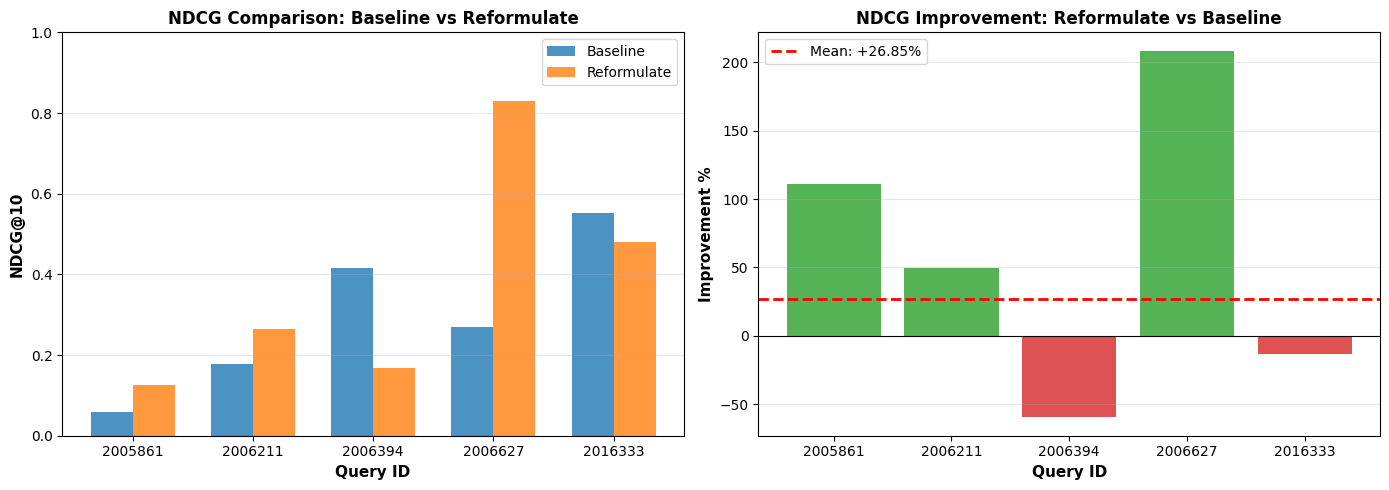


✓ Visualization complete


In [39]:
# ============================================================================
# CELL 5: COMPARATIVE RESULTS TABLE AND VISUALIZATION
# ============================================================================

print("\n" + "="*80)
print(f"COMPARISON TABLE: BASELINE vs BM25+{selected_agent_name.upper()}")
print("="*80)

comparison_data = []
for query_id in sample_queries:
    baseline_ndcg = baseline_ndcg_scores[query_id]
    agent_ndcg = agent_ndcg_scores[query_id]
    improvement = agent_ndcg - baseline_ndcg
    improvement_pct = (improvement / baseline_ndcg * 100) if baseline_ndcg > 0 else 0
    
    comparison_data.append({
        'Query ID': query_id,
        'Baseline NDCG': f"{baseline_ndcg:.4f}",
        f'{selected_agent_name} NDCG': f"{agent_ndcg:.4f}",
        'Δ NDCG': f"{improvement:+.4f}",
        'Δ %': f"{improvement_pct:+.2f}%"
    })

df_comparison = pd.DataFrame(comparison_data)

# Display all rows (no truncation)
with pd.option_context('display.max_rows', None):
    print("\n" + df_comparison.to_string(index=False))

print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
mean_improvement = agent_mean - baseline_mean

print(f"Baseline Mean NDCG@{TOP_K}: {baseline_mean:.4f}")
print(f"{selected_agent_name} Mean NDCG@{TOP_K}: {agent_mean:.4f}")
print(f"Mean Improvement: {mean_improvement:+.4f}")
print(f"Mean Improvement %: {(mean_improvement/baseline_mean*100):+.2f}%")

queries_improved = sum(1 for qid in sample_queries if agent_ndcg_scores[qid] > baseline_ndcg_scores[qid])
print(f"Queries Improved: {queries_improved}/{len(sample_queries)}")
print("="*80)

# ===== VISUALIZATION =====
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: NDCG Comparison Bar Chart
query_ids_str = [str(qid) for qid in sample_queries]
baseline_scores = [baseline_ndcg_scores[qid] for qid in sample_queries]
agent_scores = [agent_ndcg_scores[qid] for qid in sample_queries]

x = np.arange(len(query_ids_str))
width = 0.35

axes[0].bar(x - width/2, baseline_scores, width, label='Baseline', alpha=0.8, color='#1f77b4')
axes[0].bar(x + width/2, agent_scores, width, label=selected_agent_name, alpha=0.8, color='#ff7f0e')
axes[0].set_xlabel('Query ID', fontsize=11, fontweight='bold')
axes[0].set_ylabel(f'NDCG@{TOP_K}', fontsize=11, fontweight='bold')
axes[0].set_title(f'NDCG Comparison: Baseline vs {selected_agent_name}', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(query_ids_str)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1.0])

# Plot 2: Improvement Percentage
improvements = []
colors = []
for qid in sample_queries:
    imp = ((agent_ndcg_scores[qid] - baseline_ndcg_scores[qid]) / baseline_ndcg_scores[qid] * 100) if baseline_ndcg_scores[qid] > 0 else 0
    improvements.append(imp)
    colors.append('#2ca02c' if imp >= 0 else '#d62728')

axes[1].bar(query_ids_str, improvements, color=colors, alpha=0.8)
axes[1].set_xlabel('Query ID', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Improvement %', fontsize=11, fontweight='bold')
axes[1].set_title(f'NDCG Improvement: {selected_agent_name} vs Baseline', fontsize=12, fontweight='bold')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1].grid(axis='y', alpha=0.3)
axes[1].axhline(y=mean_improvement/baseline_mean*100, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_improvement/baseline_mean*100:+.2f}%')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n✓ Visualization complete")